# AT-DJ 02c — COT Best-Tanda Analysis

This notebook analyzes the **newest 02b output**:

`cot_llm_02a_feature_map_combo_average_best_tanda_results.json`

The key change from the older 02c is that the primary evaluation target is now the **best valid tanda**, not the top individual songs.

## What this notebook checks

1. Whether the LLM selected sensible **02a original numeric features**.
2. Whether predicted feature ranges are valid and selective.
3. Whether each returned primary output is a valid tanda:
   - `tango` → 4 songs
   - `vals` / `milonga` → 3 songs
   - all songs share the same `combo_key`
4. Whether candidate tanda ranking is reasonable using average song score.
5. Whether top/bottom individual songs make sense as **sanity checks only**.

This notebook does **not** create collapsed/engineered features. It analyzes only the artifacts from 02a and 02b.

## 0. Imports

In [1]:
from pathlib import Path
import json
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## 1. Mount Drive and load 02a / 02b artifacts

In [2]:
from google.colab import drive
try:
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped or unavailable:", e)

Mounted at /content/drive


In [3]:
# Adjust this if your 02a/02b artifacts are saved somewhere else.
ARTIFACT_DIR = Path("drive/MyDrive/GenAI/proj/atdj_features_exp")

results_path = ARTIFACT_DIR / "cot_llm_02a_feature_map_combo_average_best_tanda_results.json"
df_path = ARTIFACT_DIR / "df_merged.pkl"
feature_catalog_path = ARTIFACT_DIR / "feature_catalog.pkl"

if not results_path.exists():
    raise FileNotFoundError(
        f"Missing {results_path}. Run the newest 02b first, or upload the JSON artifact to ARTIFACT_DIR."
    )

with open(results_path, "r", encoding="utf-8") as f:
    all_results = json.load(f)

if df_path.exists():
    df_merged = pd.read_pickle(df_path)
else:
    df_merged = None
    print("Warning: df_merged.pkl not found. Range analysis will be skipped.")

if feature_catalog_path.exists():
    with open(feature_catalog_path, "rb") as f:
        FEATURE_CATALOG_SELECTED = pickle.load(f)
else:
    FEATURE_CATALOG_SELECTED = None
    print("Warning: feature_catalog.pkl not found. Feature-map validation will be skipped.")

print(f"Loaded {len(all_results)} prompt results from:", results_path)
if df_merged is not None:
    print("df_merged shape:", df_merged.shape)
if FEATURE_CATALOG_SELECTED is not None:
    print("feature groups:", list(FEATURE_CATALOG_SELECTED.keys()))

Loaded 7 prompt results from: drive/MyDrive/GenAI/proj/atdj_features_exp/cot_llm_02a_feature_map_combo_average_best_tanda_results.json
df_merged shape: (294, 94)
feature groups: ['categorical_metadata', 'numeric_metadata', 'rhythm_tempo', 'harmony_key', 'energy_dynamics', 'spectral_timbre', 'mirex_mood', 'jamendo_genre', 'jamendo_instrument', 'jamendo_mood_function', 'essentia_mood']


## 2. Helper functions for the newest 02b result schema

In [4]:
def flatten_feature_catalog(feature_catalog):
    # Return {feature_name: description} from 02a feature_catalog.pkl.
    if feature_catalog is None:
        return {}
    out = {}
    for group, feats in feature_catalog.items():
        for fname, desc in feats:
            out[fname] = desc
    return out

FEATURE_DESC_MAP_02A = flatten_feature_catalog(FEATURE_CATALOG_SELECTED)
ALLOWED_02A_FEATURES = set(FEATURE_DESC_MAP_02A)

IDENTITY_CONTEXT_FIELDS = {"title", "orchestra", "singer", "album", "filename"}
GROUPING_FIELD = "combo_key"
HARD_CONSTRAINT_FIELDS = {"style", "year", "decade"}
FORBIDDEN_SCORING_FIELDS = IDENTITY_CONTEXT_FIELDS | {GROUPING_FIELD} | HARD_CONSTRAINT_FIELDS

def infer_tanda_size(style_value):
    style = str(style_value).lower().strip() if style_value is not None else ""
    if style == "tango":
        return 4
    if style in {"vals", "milonga"}:
        return 3
    return 4

def get_best_tanda(result):
    return result.get("best_tanda")

def get_tanda_tracks(tanda):
    if not tanda:
        return []
    return tanda.get("tracks", []) or []

def safe_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan

## 3. Summary of prompts and primary outputs

In [5]:
summary_rows = []
for r in all_results:
    tanda = get_best_tanda(r)
    metadata = r.get("metadata", {}) or {}
    base = {
        "prompt": r.get("prompt"),
        "n_valid_tanda_candidates": metadata.get("n_valid_tanda_candidates"),
        "n_candidate_tracks_after_constraints": metadata.get("n_candidate_tracks_after_constraints"),
        "latency_seconds": metadata.get("latency_seconds"),
    }
    if tanda is None:
        base.update({"has_best_tanda": False, "combo_key": None, "style": None, "tanda_size": None, "tanda_score": np.nan})
    else:
        base.update({
            "has_best_tanda": True,
            "combo_key": tanda.get("combo_key"),
            "style": tanda.get("style"),
            "tanda_size": tanda.get("tanda_size"),
            "tanda_score": tanda.get("tanda_score"),
            "n_available_in_combo": tanda.get("n_available_in_combo"),
        })
    summary_rows.append(base)

summary_df = pd.DataFrame(summary_rows)
summary_df

,prompt,n_valid_tanda_candidates,n_candidate_tracks_after_constraints,latency_seconds,has_best_tanda,combo_key,style,tanda_size,tanda_score,n_available_in_combo
0,energetic tango with strong rhythm for experie...,5,216,8.905,True,enrique rodriguez | armando moreno | tango,tango,4,0.999507,6
1,"melancholic and slow, perfect for a late-night...",5,41,14.934,True,juan d'arienzo | instrumental | vals,vals,3,0.880401,13
2,bright and cheerful milonga with clear melody,5,37,7.562,True,juan d'arienzo | alberto echagüe | milonga,milonga,3,0.975104,8
3,dramatic tango with heavy bandoneon and dark mood,5,216,7.828,True,alfredo de angelis | julio martel | tango,tango,4,0.942812,6
4,"smooth and relaxed, good for warming up the floor",5,294,6.271,True,juan d'arienzo | instrumental | vals,vals,3,0.995849,13
5,"classic golden-age tango from the 40s, warm an...",5,294,9.555,True,alfredo gobbi | instrumental | tango,tango,4,0.995761,6
6,a lively vals from the 50s with a strong orche...,5,294,7.234,True,anibal troilo | instrumental | tango,tango,4,1.000000,6


In [6]:
print("Primary-output availability:")
print(summary_df["has_best_tanda"].value_counts(dropna=False).to_string())

if summary_df["tanda_score"].notna().any():
    print("\nTanda score summary:")
    print(summary_df["tanda_score"].describe().to_string())

if "latency_seconds" in summary_df:
    print("\nLatency summary:")
    print(pd.to_numeric(summary_df["latency_seconds"], errors="coerce").describe().to_string())

Primary-output availability:
has_best_tanda
True    7

Tanda score summary:
count    7.000000
mean     0.969919
std      0.044526
min      0.880401
25%      0.958958
50%      0.995761
75%      0.997678
max      1.000000

Latency summary:
count     7.000000
mean      8.898429
std       2.871260
min       6.271000
25%       7.398000
50%       7.828000
75%       9.230000
max      14.934000


## 4. Feature-selection frequency from the LLM

Selected feature frequency:
                                                           feature  count  pct_prompts                                                        description_from_02a
                                                               bpm      7   100.000000                                          Beats per minute — estimated tempo
                                                  average_loudness      7   100.000000                                                            Average loudness
                                                      danceability      6    85.714286                                                 Essentia danceability score
                                                      key_strength      4    57.142857                            Confidence/strength of the estimated musical key
                                                      mood_relaxed      4    57.142857                                           Essentia mood classifier: re

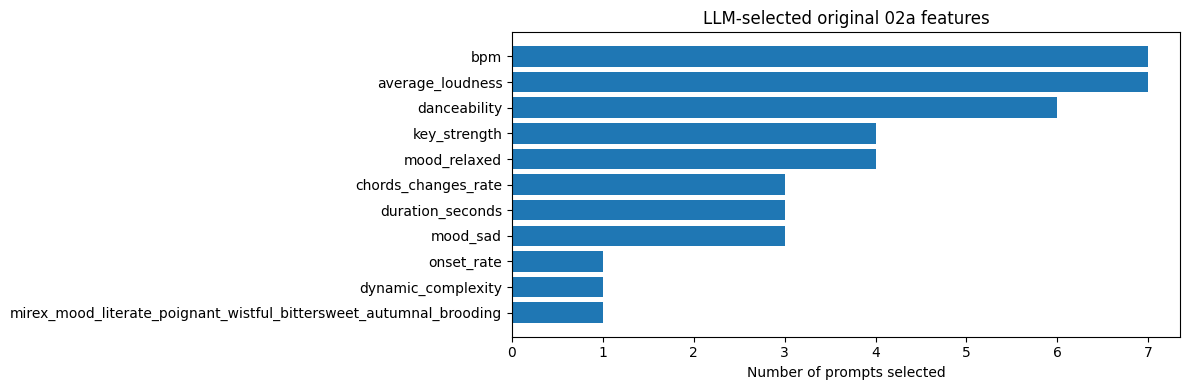

In [7]:
feature_counter = Counter()
invalid_feature_counter = Counter()
for r in all_results:
    used = r.get("feature_ranges_used", {}) or {}
    feature_counter.update(used.keys())
    for f in used.keys():
        if f in FORBIDDEN_SCORING_FIELDS or (ALLOWED_02A_FEATURES and f not in ALLOWED_02A_FEATURES):
            invalid_feature_counter[f] += 1

freq_df = pd.DataFrame(feature_counter.items(), columns=["feature", "count"]).sort_values("count", ascending=False)
if len(freq_df):
    freq_df["pct_prompts"] = freq_df["count"] / len(all_results) * 100
    if FEATURE_DESC_MAP_02A:
        freq_df["description_from_02a"] = freq_df["feature"].map(FEATURE_DESC_MAP_02A)

print("Selected feature frequency:")
print(freq_df.to_string(index=False))

print("\nInvalid or forbidden scoring features selected by the LLM after 02b filtering:")
if invalid_feature_counter:
    print(pd.DataFrame(invalid_feature_counter.items(), columns=["feature", "count"]).to_string(index=False))
else:
    print("None found. Good: 02b kept scoring features inside the allowed 02a numeric feature set.")

if len(freq_df):
    plt.figure(figsize=(12, max(4, 0.35 * len(freq_df))))
    plt.barh(freq_df["feature"][::-1], freq_df["count"][::-1])
    plt.xlabel("Number of prompts selected")
    plt.title("LLM-selected original 02a features")
    plt.tight_layout()
    plt.show()

## 5. Weight distribution

                                                                    count      mean       std   min   max
feature                                                                                                  
average_loudness                                                        7  0.264286  0.193033  0.15  0.70
bpm                                                                     7  0.350000  0.200000  0.25  0.80
danceability                                                            6  0.266667  0.068313  0.20  0.40
mood_relaxed                                                            4  0.337500  0.179699  0.20  0.60
key_strength                                                            4  0.300000  0.267706  0.15  0.70
chords_changes_rate                                                     3  0.266667  0.202073  0.15  0.50
duration_seconds                                                        3  0.200000  0.000000  0.20  0.20
mood_sad                                      

/tmp/ipykernel_14300/2214639489.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([plot_data[i] for i in order], vert=False, labels=[labels[i] for i in order])


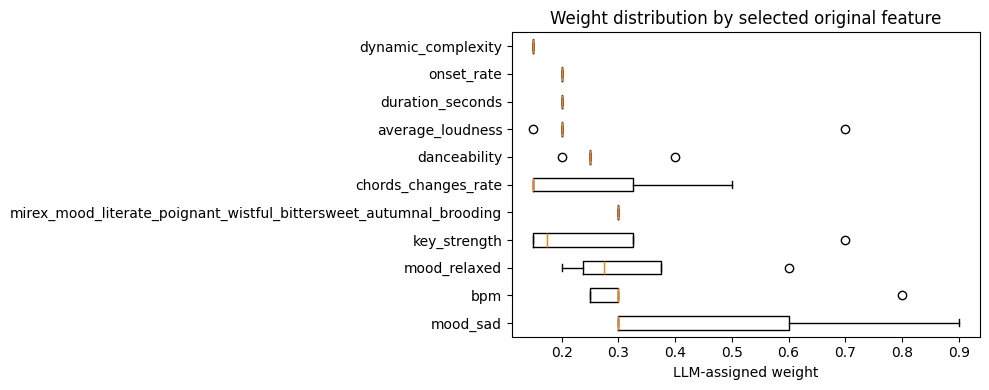

In [8]:
weight_rows = []
for r in all_results:
    for f, spec in (r.get("feature_ranges_used", {}) or {}).items():
        weight_rows.append({
            "prompt": r.get("prompt"),
            "feature": f,
            "weight": safe_float(spec.get("weight")),
            "direction": spec.get("direction"),
            "why": spec.get("why"),
        })

weights_df = pd.DataFrame(weight_rows)
if len(weights_df):
    print(weights_df.groupby("feature")["weight"].agg(["count", "mean", "std", "min", "max"]).sort_values("count", ascending=False).to_string())
    plot_data, labels = [], []
    for f, g in weights_df.groupby("feature"):
        vals = g["weight"].dropna().values
        if len(vals):
            plot_data.append(vals)
            labels.append(f)
    if plot_data:
        order = np.argsort([np.nanmean(x) for x in plot_data])[::-1]
        plt.figure(figsize=(10, max(4, 0.35 * len(labels))))
        plt.boxplot([plot_data[i] for i in order], vert=False, labels=[labels[i] for i in order])
        plt.xlabel("LLM-assigned weight")
        plt.title("Weight distribution by selected original feature")
        plt.tight_layout()
        plt.show()
else:
    print("No feature weights found.")

## 6. Range validity and selectivity

                                                    prompt                                                            feature     direction   pred_min   pred_max   data_min   data_max  width_ratio_vs_data  song_coverage_pct_full_dataset  out_of_observed_bounds  candidate_pool_size_after_constraints
        a lively vals from the 50s with a strong orchestra                                                   average_loudness higher_better   0.500000   0.900000   0.080937   0.955123             0.457569                       65.306122                   False                                    294
        a lively vals from the 50s with a strong orchestra                                                                bpm higher_better 120.000000 180.000000  90.882782 184.570587             0.640425                       60.544218                   False                                    294
        a lively vals from the 50s with a strong orchestra                                          

/tmp/ipykernel_14300/2457871558.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, vert=False, labels=labels)


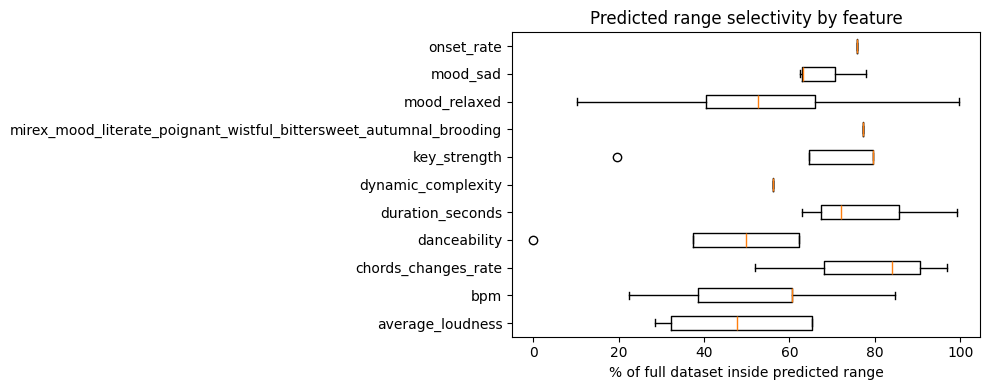

In [9]:
range_rows = []
if df_merged is None:
    print("df_merged unavailable; skipping data-bound range analysis.")
else:
    for r in all_results:
        candidate_n = (r.get("metadata", {}) or {}).get("n_candidate_tracks_after_constraints")
        for f, spec in (r.get("feature_ranges_used", {}) or {}).items():
            if f not in df_merged.columns:
                continue
            col = pd.to_numeric(df_merged[f], errors="coerce").dropna()
            if len(col) == 0:
                continue
            data_min, data_max = float(col.min()), float(col.max())
            lo, hi = safe_float(spec.get("min")), safe_float(spec.get("max"))
            direction = spec.get("direction")

            if np.isnan(lo) or np.isnan(hi):
                width_ratio = np.nan
                coverage_pct = np.nan
                out_of_bounds = np.nan
            else:
                if hi < lo:
                    lo, hi = hi, lo
                denom = data_max - data_min
                width_ratio = (hi - lo) / denom if denom > 0 else np.nan
                clipped_lo, clipped_hi = max(lo, data_min), min(hi, data_max)
                coverage_pct = col.between(clipped_lo, clipped_hi).mean() * 100
                out_of_bounds = (lo < data_min) or (hi > data_max)

            range_rows.append({
                "prompt": r.get("prompt"), "feature": f, "direction": direction,
                "pred_min": lo, "pred_max": hi, "data_min": data_min, "data_max": data_max,
                "width_ratio_vs_data": width_ratio,
                "song_coverage_pct_full_dataset": coverage_pct,
                "out_of_observed_bounds": out_of_bounds,
                "candidate_pool_size_after_constraints": candidate_n,
            })

range_df = pd.DataFrame(range_rows)
if len(range_df):
    print(range_df.sort_values(["prompt", "feature"]).to_string(index=False))
    print("\nRange selectivity summary by feature:")
    print(range_df.groupby("feature")["song_coverage_pct_full_dataset"].agg(["count", "mean", "min", "max"]).sort_values("mean").to_string())

    plt.figure(figsize=(10, max(4, 0.35 * range_df["feature"].nunique())))
    data = [g["song_coverage_pct_full_dataset"].dropna().values for _, g in range_df.groupby("feature")]
    labels = [f for f, _ in range_df.groupby("feature")]
    plt.boxplot(data, vert=False, labels=labels)
    plt.xlabel("% of full dataset inside predicted range")
    plt.title("Predicted range selectivity by feature")
    plt.tight_layout()
    plt.show()
else:
    print("No range rows available.")

## 7. Best-tanda validity checks

In [10]:
validity_rows = []
for r in all_results:
    prompt = r.get("prompt")
    constraints = r.get("hard_constraints", {}) or {}
    tanda = get_best_tanda(r)

    if tanda is None:
        validity_rows.append({"prompt": prompt, "has_tanda": False, "valid_combo_key": False, "valid_size": False, "valid_style_constraint": False, "valid_decade_constraint": False, "computed_avg_score": np.nan, "reported_tanda_score": np.nan, "score_match": False})
        continue

    tracks = get_tanda_tracks(tanda)
    combo_keys = {t.get("combo_key") for t in tracks}
    styles = {str(t.get("style")).lower().strip() for t in tracks if t.get("style") is not None}
    decades = {safe_float(t.get("decade")) for t in tracks if t.get("decade") is not None}
    decades = {int(d) for d in decades if not np.isnan(d)}

    style = tanda.get("style")
    required_size = infer_tanda_size(style)
    scores = [safe_float(t.get("score")) for t in tracks]
    computed_avg = float(np.nanmean(scores)) if scores else np.nan
    reported_score = safe_float(tanda.get("tanda_score"))

    valid_combo_key = len(combo_keys) == 1 and next(iter(combo_keys)) == tanda.get("combo_key")
    valid_size = len(tracks) == required_size == tanda.get("tanda_size")
    valid_style_constraint = True
    if "style" in constraints:
        valid_style_constraint = len(styles) > 0 and styles == {constraints["style"]}
    valid_decade_constraint = True
    if "decade" in constraints:
        valid_decade_constraint = len(decades) > 0 and decades == {int(constraints["decade"])}

    validity_rows.append({
        "prompt": prompt, "has_tanda": True, "combo_key": tanda.get("combo_key"), "style": style,
        "required_size": required_size, "returned_size": len(tracks), "reported_tanda_size": tanda.get("tanda_size"),
        "valid_combo_key": valid_combo_key, "valid_size": valid_size,
        "valid_style_constraint": valid_style_constraint, "valid_decade_constraint": valid_decade_constraint,
        "computed_avg_score": computed_avg, "reported_tanda_score": reported_score,
        "score_match": np.isclose(computed_avg, reported_score, atol=1e-9),
    })

validity_df = pd.DataFrame(validity_rows)
validity_df

,prompt,has_tanda,combo_key,style,required_size,returned_size,reported_tanda_size,valid_combo_key,valid_size,valid_style_constraint,valid_decade_constraint,computed_avg_score,reported_tanda_score,score_match
0,energetic tango with strong rhythm for experie...,True,enrique rodriguez | armando moreno | tango,tango,4,4,4,True,True,True,True,0.999507,0.999507,True
1,"melancholic and slow, perfect for a late-night...",True,juan d'arienzo | instrumental | vals,vals,3,3,3,True,True,True,True,0.880401,0.880401,True
2,bright and cheerful milonga with clear melody,True,juan d'arienzo | alberto echagüe | milonga,milonga,3,3,3,True,True,True,True,0.975104,0.975104,True
3,dramatic tango with heavy bandoneon and dark mood,True,alfredo de angelis | julio martel | tango,tango,4,4,4,True,True,True,True,0.942812,0.942812,True
4,"smooth and relaxed, good for warming up the floor",True,juan d'arienzo | instrumental | vals,vals,3,3,3,True,True,True,True,0.995849,0.995849,True
5,"classic golden-age tango from the 40s, warm an...",True,alfredo gobbi | instrumental | tango,tango,4,4,4,True,True,True,False,0.995761,0.995761,True
6,a lively vals from the 50s with a strong orche...,True,anibal troilo | instrumental | tango,tango,4,4,4,True,True,False,False,1.000000,1.000000,True


In [11]:
check_cols = ["has_tanda", "valid_combo_key", "valid_size", "valid_style_constraint", "valid_decade_constraint", "score_match"]
print("Validity pass rates:")
for c in check_cols:
    if c in validity_df:
        print(f"{c}: {validity_df[c].mean() * 100:.1f}%")

bad = validity_df[~validity_df[check_cols].all(axis=1)] if len(validity_df) else pd.DataFrame()
if len(bad):
    print("\nRows needing inspection:")
    print(bad.to_string(index=False))
else:
    print("\nAll best-tanda outputs passed structural checks.")

Validity pass rates:
has_tanda: 100.0%
valid_combo_key: 100.0%
valid_size: 100.0%
valid_style_constraint: 85.7%
valid_decade_constraint: 71.4%
score_match: 100.0%

Rows needing inspection:
                                                   prompt  has_tanda                            combo_key style  required_size  returned_size  reported_tanda_size  valid_combo_key  valid_size  valid_style_constraint  valid_decade_constraint  computed_avg_score  reported_tanda_score  score_match
classic golden-age tango from the 40s, warm and nostalgic       True alfredo gobbi | instrumental | tango tango              4              4                    4             True        True                    True                    False            0.995761              0.995761         True
       a lively vals from the 50s with a strong orchestra       True anibal troilo | instrumental | tango tango              4              4                    4             True        True                   False    

## 8. Best tanda details by prompt

In [12]:
for r in all_results:
    print("\n" + "=" * 100)
    print("PROMPT:", r.get("prompt"))
    print("Hard constraints:", r.get("hard_constraints", {}))
    print("Selected features:", list((r.get("feature_ranges_used", {}) or {}).keys()))
    print("LLM reasoning:", r.get("llm_reasoning", ""))

    tanda = get_best_tanda(r)
    if not tanda:
        print("No valid tanda returned.")
        continue

    print(
        f"BEST TANDA | avg={tanda.get('tanda_score'):.3f} | style={tanda.get('style')} | "
        f"size={tanda.get('tanda_size')} | combo={tanda.get('combo_key')} | "
        f"available_in_combo={tanda.get('n_available_in_combo')}"
    )
    for i, tr in enumerate(get_tanda_tracks(tanda), 1):
        print(
            f"  {i}. score={tr.get('score'):.3f} | "
            f"{tr.get('title')} | {tr.get('orchestra')} | {tr.get('singer')} | "
            f"style={tr.get('style')} | decade={tr.get('decade')} | file={tr.get('filename')}"
        )


PROMPT: energetic tango with strong rhythm for experienced dancers
Hard constraints: {'style': 'tango'}
Selected features: ['bpm', 'onset_rate', 'danceability', 'average_loudness', 'dynamic_complexity']
LLM reasoning: The prompt specifies a desire for energetic tango music with a strong rhythm, which suggests a focus on tempo, danceability, and rhythmic density. I selected features that reflect these qualities, particularly emphasizing bpm, onset rate, and danceability, as they directly relate to the energetic and rhythmic aspects of tango music.
BEST TANDA | avg=1.000 | style=tango | size=4 | combo=enrique rodriguez | armando moreno | tango | available_in_combo=6
  1. score=1.000 | Como Has Cambiado Pebeta | Enrique Rodriguez | Armando Moreno | style=tango | decade=1940s | file=07 como has cambiado pebeta.mp3
  2. score=1.000 | El Encopao | Enrique Rodriguez | Armando Moreno | style=tango | decade=1940s | file=09 el encopao.mp3
  3. score=1.000 | En La Buena Y En La Mala | Enrique Ro

## 9. Top candidate tanda comparison

                                                    prompt  rank                                             combo_key   style  tanda_size  tanda_score  min_track_score  max_track_score  score_spread  n_available_in_combo
energetic tango with strong rhythm for experienced dancers     1            enrique rodriguez | armando moreno | tango   tango           4     0.999507         0.998346         1.000000      0.001654                     6
energetic tango with strong rhythm for experienced dancers     2             pedro laurenz | juan carlos casas | tango   tango           4     0.999060         0.996239         1.000000      0.003761                     6
energetic tango with strong rhythm for experienced dancers     3                      miguel caló | raúl berón | tango   tango           4     0.998147         0.995523         1.000000      0.004477                     6
energetic tango with strong rhythm for experienced dancers     4                     lucio demare | raúl berón |

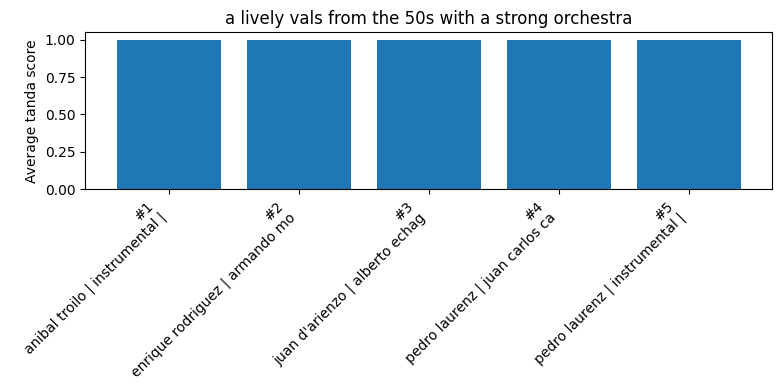

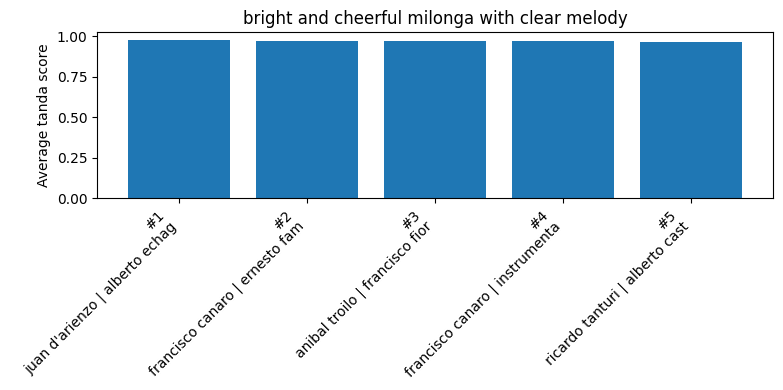

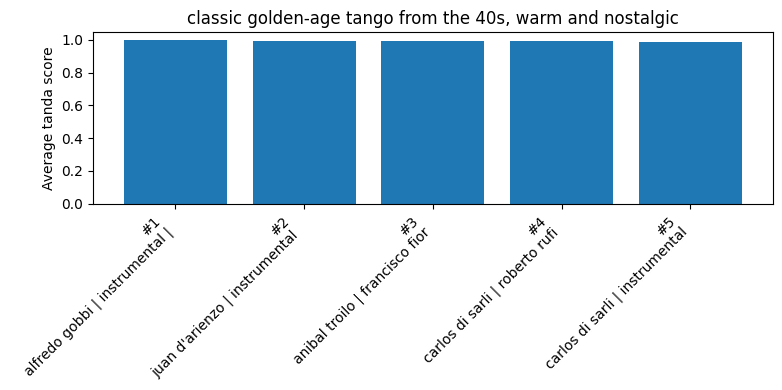

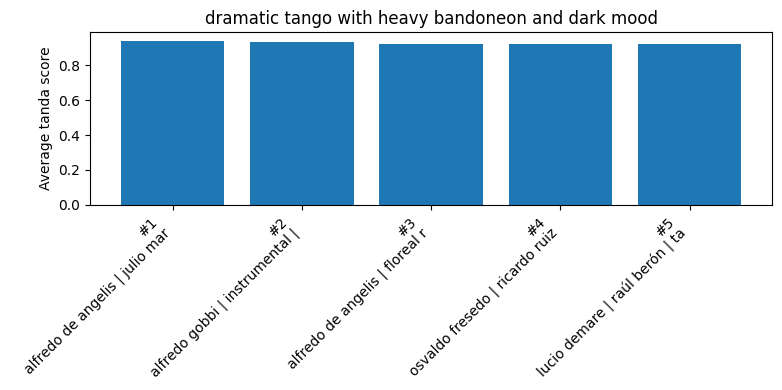

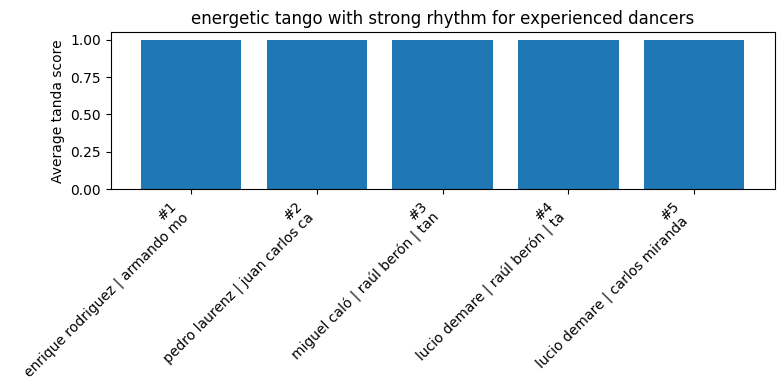

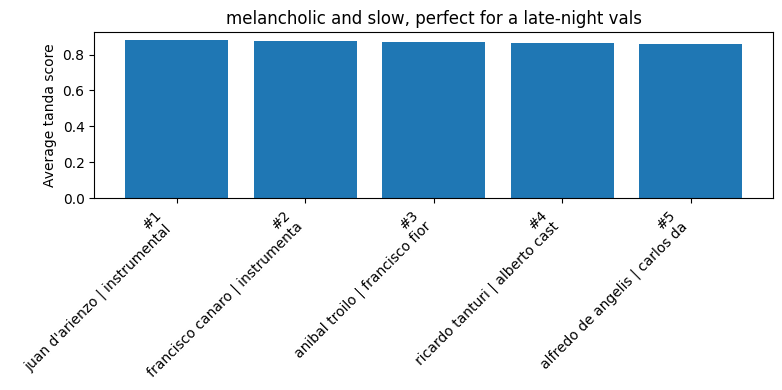

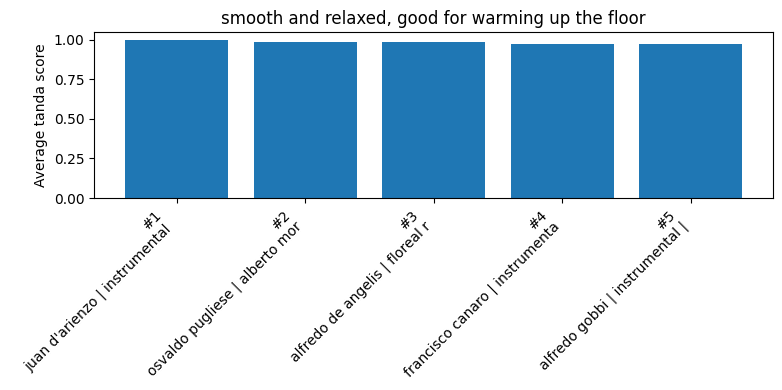

In [14]:
candidate_rows = []

for r in all_results:
    for rank, cand in enumerate(r.get("top_candidate_tandas", []) or [], start=1):
        scores = [safe_float(t.get("score")) for t in get_tanda_tracks(cand)]
        scores = [s for s in scores if not pd.isna(s)]

        candidate_rows.append({
            "prompt": r.get("prompt"),
            "rank": rank,
            "combo_key": cand.get("combo_key"),
            "style": cand.get("style"),
            "tanda_size": cand.get("tanda_size"),
            "tanda_score": safe_float(cand.get("tanda_score")),
            "min_track_score": np.nanmin(scores) if scores else np.nan,
            "max_track_score": np.nanmax(scores) if scores else np.nan,
            "score_spread": (np.nanmax(scores) - np.nanmin(scores)) if scores else np.nan,
            "n_available_in_combo": cand.get("n_available_in_combo"),
        })

candidate_tandas_df = pd.DataFrame(candidate_rows)

if len(candidate_tandas_df):
    print(candidate_tandas_df.to_string(index=False))

    for prompt, g in candidate_tandas_df.groupby("prompt"):
        g = g.sort_values("rank")

        plt.figure(figsize=(8, 4))

        labels = [
            f"#{int(row['rank'])}\n{str(row['combo_key'])[:30]}"
            for _, row in g.iterrows()
        ]

        plt.bar(labels, g["tanda_score"].astype(float))
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Average tanda score")
        plt.title(str(prompt)[:90])
        plt.tight_layout()
        plt.show()
else:
    print("No candidate tandas found in results.")

## 10. Sanity-check individual songs: top and bottom scores

In [15]:
top_rows = []
bottom_rows = []
for r in all_results:
    best_combo = (get_best_tanda(r) or {}).get("combo_key")
    for rank, song in enumerate(r.get("sanity_check_top_k_songs", []) or [], start=1):
        top_rows.append({
            "prompt": r.get("prompt"), "rank": rank, "score": song.get("score"),
            "title": song.get("title"), "orchestra": song.get("orchestra"), "singer": song.get("singer"),
            "style": song.get("style"), "decade": song.get("decade"), "filename": song.get("filename"),
            "combo_key": song.get("combo_key"), "same_combo_as_best_tanda": song.get("combo_key") == best_combo,
        })
    for rank, song in enumerate(r.get("sanity_check_bottom_k_songs", []) or [], start=1):
        bottom_rows.append({
            "prompt": r.get("prompt"), "rank": rank, "score": song.get("score"),
            "title": song.get("title"), "orchestra": song.get("orchestra"), "singer": song.get("singer"),
            "style": song.get("style"), "decade": song.get("decade"), "filename": song.get("filename"),
            "combo_key": song.get("combo_key"),
        })

top_songs_df = pd.DataFrame(top_rows)
bottom_songs_df = pd.DataFrame(bottom_rows)

print("Top individual songs — sanity check only:")
if len(top_songs_df):
    print(top_songs_df.head(80).to_string(index=False))
    print("\n% top individual songs in the same combo as best tanda:")
    print((top_songs_df.groupby("prompt")["same_combo_as_best_tanda"].mean() * 100).round(1).to_string())

print("\nBottom individual songs — sanity check only:")
if len(bottom_songs_df):
    print(bottom_songs_df.head(60).to_string(index=False))

Top individual songs — sanity check only:
                                                    prompt  rank    score                      title          orchestra                    singer   style decade                          filename                                              combo_key  same_combo_as_best_tanda
energetic tango with strong rhythm for experienced dancers     1 1.000000          Bajo El Cono Azul Alfredo De Angelis              Floreal Ruiz   tango  1940s          06 bajo el cono azul.mp3              alfredo de angelis | floreal ruiz | tango                     False
energetic tango with strong rhythm for experienced dancers     2 1.000000              Altar Sin Luz Alfredo De Angelis              Julio Martel   tango  1940s              22 altar sin luz.mp3              alfredo de angelis | julio martel | tango                     False
energetic tango with strong rhythm for experienced dancers     3 1.000000                   Shusheta    Carlos Di Sarli           

## 11. Why top songs are not the final output

In [16]:
comparison_rows = []
for r in all_results:
    prompt = r.get("prompt")
    tanda = get_best_tanda(r)
    if not tanda:
        continue
    best_combo = tanda.get("combo_key")
    top_songs = r.get("sanity_check_top_k_songs", []) or []
    top_k_scores = [safe_float(s.get("score")) for s in top_songs]
    top_k_combos = [s.get("combo_key") for s in top_songs]
    n_unique_top_combos = len(set(top_k_combos))
    top_songs_same_combo = sum(1 for c in top_k_combos if c == best_combo)
    tanda_scores = [safe_float(t.get("score")) for t in get_tanda_tracks(tanda)]

    comparison_rows.append({
        "prompt": prompt,
        "best_tanda_combo": best_combo,
        "best_tanda_score_avg": tanda.get("tanda_score"),
        "best_tanda_min_track_score": np.nanmin(tanda_scores),
        "best_tanda_max_track_score": np.nanmax(tanda_scores),
        "top_individual_score": np.nanmax(top_k_scores) if top_k_scores else np.nan,
        "top_k_unique_combos": n_unique_top_combos,
        "top_k_songs_in_best_combo": top_songs_same_combo,
        "why_it_matters": "Top songs may be spread across combos; final tanda must be one combo_key.",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,prompt,best_tanda_combo,best_tanda_score_avg,best_tanda_min_track_score,best_tanda_max_track_score,top_individual_score,top_k_unique_combos,top_k_songs_in_best_combo,why_it_matters
0,energetic tango with strong rhythm for experie...,enrique rodriguez | armando moreno | tango,0.999507,0.998346,1.000000,1.000000,7,0,Top songs may be spread across combos; final t...
1,"melancholic and slow, perfect for a late-night...",juan d'arienzo | instrumental | vals,0.880401,0.877114,0.882353,0.882353,5,3,Top songs may be spread across combos; final t...
2,bright and cheerful milonga with clear melody,juan d'arienzo | alberto echagüe | milonga,0.975104,0.968617,0.981003,1.000000,6,3,Top songs may be spread across combos; final t...
3,dramatic tango with heavy bandoneon and dark mood,alfredo de angelis | julio martel | tango,0.942812,0.930306,0.954753,0.969645,8,2,Top songs may be spread across combos; final t...
4,"smooth and relaxed, good for warming up the floor",juan d'arienzo | instrumental | vals,0.995849,0.993037,0.999327,1.000000,9,2,Top songs may be spread across combos; final t...
5,"classic golden-age tango from the 40s, warm an...",alfredo gobbi | instrumental | tango,0.995761,0.993225,1.000000,1.000000,10,1,Top songs may be spread across combos; final t...
6,a lively vals from the 50s with a strong orche...,anibal troilo | instrumental | tango,1.000000,1.000000,1.000000,1.000000,5,0,Top songs may be spread across combos; final t...


## 12. Feature explanations inside the chosen best tanda

In [17]:
matched_rows = []
for r in all_results:
    prompt = r.get("prompt")
    tanda = get_best_tanda(r)
    if not tanda:
        continue
    for track_rank, tr in enumerate(get_tanda_tracks(tanda), start=1):
        for f, info in (tr.get("matched_features", {}) or {}).items():
            matched_rows.append({
                "prompt": prompt, "track_rank": track_rank, "track_score": tr.get("score"),
                "title": tr.get("title"), "combo_key": tr.get("combo_key"),
                "feature": f, "value": info.get("value"),
                "feature_score": info.get("feature_score"), "weight": info.get("weight"),
            })

matched_best_tanda_features_df = pd.DataFrame(matched_rows)
if len(matched_best_tanda_features_df):
    print(matched_best_tanda_features_df.head(120).to_string(index=False))
    matched_best_tanda_features_df["weighted_feature_score"] = (
        pd.to_numeric(matched_best_tanda_features_df["feature_score"], errors="coerce")
        * pd.to_numeric(matched_best_tanda_features_df["weight"], errors="coerce")
    )
    print("\nAverage weighted feature score within best tandas:")
    print(
        matched_best_tanda_features_df.groupby("feature")["weighted_feature_score"]
        .agg(["count", "mean", "min", "max"])
        .sort_values("mean", ascending=False)
        .to_string()
    )
else:
    print("No matched feature rows found.")

                                                    prompt  track_rank  track_score                      title                                  combo_key                                                            feature      value  feature_score  weight
energetic tango with strong rhythm for experienced dancers           1     1.000000   Como Has Cambiado Pebeta enrique rodriguez | armando moreno | tango                                                                bpm 125.848495       1.000000    0.25
energetic tango with strong rhythm for experienced dancers           1     1.000000   Como Has Cambiado Pebeta enrique rodriguez | armando moreno | tango                                                         onset_rate   3.281794       1.000000    0.20
energetic tango with strong rhythm for experienced dancers           1     1.000000   Como Has Cambiado Pebeta enrique rodriguez | armando moreno | tango                                                       danceability   1.072271    

## 13. Draft findings template

In [18]:
most_selected = ", ".join(freq_df.head(5)["feature"].tolist()) if len(freq_df) else "N/A"
mean_oob = range_df["out_of_observed_bounds"].dropna().mean() * 100 if "range_df" in globals() and len(range_df) else 0
mean_cov = range_df["song_coverage_pct_full_dataset"].dropna().mean() if "range_df" in globals() and len(range_df) else 0
valid_combo_rate = validity_df["valid_combo_key"].mean() * 100 if len(validity_df) else 0
valid_size_rate = validity_df["valid_size"].mean() * 100 if len(validity_df) else 0
has_tanda_rate = validity_df["has_tanda"].mean() * 100 if len(validity_df) else 0
mean_tanda_score = summary_df["tanda_score"].dropna().mean() if len(summary_df) else np.nan

print(f"""
Draft findings:
- The updated 02c evaluates the newest 02b pipeline where the primary output is the best valid tanda, not the top individual songs.
- 02b uses the 02a feature map as the source of truth and scores only original numeric features selected by 02a.
- The most frequently selected scoring features were: {most_selected}.
- Predicted feature ranges covered about {mean_cov:.1f}% of the full dataset on average; this is a rough measure of how selective the LLM's COT ranges were.
- {mean_oob:.1f}% of predicted ranges extended outside observed data bounds, which may indicate range-calibration issues.
- A valid best tanda was returned for {has_tanda_rate:.1f}% of prompts.
- Best-tanda combo-key validity rate: {valid_combo_rate:.1f}%.
- Best-tanda size validity rate: {valid_size_rate:.1f}%.
- Mean best-tanda average score: {mean_tanda_score:.3f}.
- Top/bottom individual songs should be interpreted only as sanity checks because the highest-scoring individual tracks can come from different combo_keys and therefore cannot necessarily form a valid tanda.
""")


Draft findings:
- The updated 02c evaluates the newest 02b pipeline where the primary output is the best valid tanda, not the top individual songs.
- 02b uses the 02a feature map as the source of truth and scores only original numeric features selected by 02a.
- The most frequently selected scoring features were: bpm, average_loudness, danceability, key_strength, mood_relaxed.
- Predicted feature ranges covered about 58.0% of the full dataset on average; this is a rough measure of how selective the LLM's COT ranges were.
- 25.0% of predicted ranges extended outside observed data bounds, which may indicate range-calibration issues.
- A valid best tanda was returned for 100.0% of prompts.
- Best-tanda combo-key validity rate: 100.0%.
- Best-tanda size validity rate: 100.0%.
- Mean best-tanda average score: 0.970.
- Top/bottom individual songs should be interpreted only as sanity checks because the highest-scoring individual tracks can come from different combo_keys and therefore cannot 

## 14. Optional: save analysis tables

In [19]:
analysis_dir = ARTIFACT_DIR / "02c_analysis_tables"
analysis_dir.mkdir(parents=True, exist_ok=True)

for name, obj in {
    "summary_df": globals().get("summary_df"),
    "freq_df": globals().get("freq_df"),
    "weights_df": globals().get("weights_df"),
    "range_df": globals().get("range_df"),
    "validity_df": globals().get("validity_df"),
    "candidate_tandas_df": globals().get("candidate_tandas_df"),
    "top_songs_df": globals().get("top_songs_df"),
    "bottom_songs_df": globals().get("bottom_songs_df"),
    "comparison_df": globals().get("comparison_df"),
    "matched_best_tanda_features_df": globals().get("matched_best_tanda_features_df"),
}.items():
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(analysis_dir / f"{name}.csv", index=False)

print("Saved analysis tables to:", analysis_dir)

Saved analysis tables to: drive/MyDrive/GenAI/proj/atdj_features_exp/02c_analysis_tables
